<a href="https://colab.research.google.com/github/nuhuynhh/IBM-Telco-Churn-Analysis/blob/main/IBM_Telco_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IBM Telco Churn Analysis**


---



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

Load Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Understand the Data using .info() and .describe()

In [7]:
df.info()
#TotalCharges's Dtype is an Object, we need to change it to a float64 or int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [9]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [10]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


# **Data** Cleaning
Before starting the analysis, we need to clean and prepare our data. This includes handling missing values, converting data types, and creating a clean dataset for analysis

In [11]:
# In this dataset, some values are stored as strings or blanks (dtype is object)
# Need to change data to numerical data
# errors = 'coerce' means that if something can't be converted the system doesn't crash it just turns into Nan
df.loc[:,'Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Drop CustomerID before one-hot encoding as it's a unique identifier
df = df.drop(['CustomerID'], axis=1)


#Remove uncessary columns such as Latitude, & longitude
df = df.drop(['Latitude','Longitude','Lat Long'], axis=1)

df.tail(20)

,Count,Country,State,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7023,1,United States,California,North Palm Springs,92258,Female,No,No,No,51,...,Two year,No,Bank transfer (automatic),20.65,1020.75,No,0,70,4725,NaN
7024,1,United States,California,Palm Desert,92260,Female,No,No,No,39,...,Two year,No,Mailed check,20.15,826.0,No,0,44,2007,NaN
7025,1,United States,California,Palm Springs,92262,Male,No,Yes,Yes,12,...,Month-to-month,Yes,Electronic check,19.20,239.0,No,0,73,3101,NaN
7026,1,United States,California,Palo Verde,92266,Male,No,No,No,72,...,One year,Yes,Electronic check,104.95,7544.3,No,0,20,5760,NaN
7027,1,United States,California,Parker Dam,92267,Female,Yes,Yes,No,63,...,Month-to-month,Yes,Electronic check,103.50,6479.4,No,0,53,5187,NaN
7028,1,United States,California,Pioneertown,92268,Male,No,Yes,No,44,...,Month-to-month,Yes,Credit card (automatic),84.80,3626.35,No,0,44,2770,NaN
7029,1,United States,California,Rancho Mirage,92270,Female,No,No,No,18,...,Month-to-month,Yes,Bank transfer (automatic),95.05,1679.4,No,0,60,4524,NaN
7030,1,United States,California,Thermal,92274,Male,No,No,No,13,...,Month-to-month,No,Mailed check,73.35,931.55,No,0,65,4645,NaN
7031,1,United States,California,Salton City,92275,Female,No,Yes,No,68,...,Two year,No,Bank transfer (automatic),64.10,4326.25,No,0,48,5553,NaN
7032,1,United States,California,Thousand Palms,92276,Female,Yes,No,No,6,...,Month-to-month,Yes,Electronic check,44.40,263.05,No,0,71,4611,NaN


# **Exploratory Data Analysis**
Now that our data is clean, let’s explore it to understand patterns and relationships that might explain customer churn.

In [12]:
# Overall Churn Rate
churn_rate = df['Churn Value'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


# **How does Distribution of Payment Methods affect Churn Rate**
Using the Seaborn library, we want to visualize the four payment methods to understand how customers are spread across each category. This is important because the differences in group size can influence how we interpet churn rate.


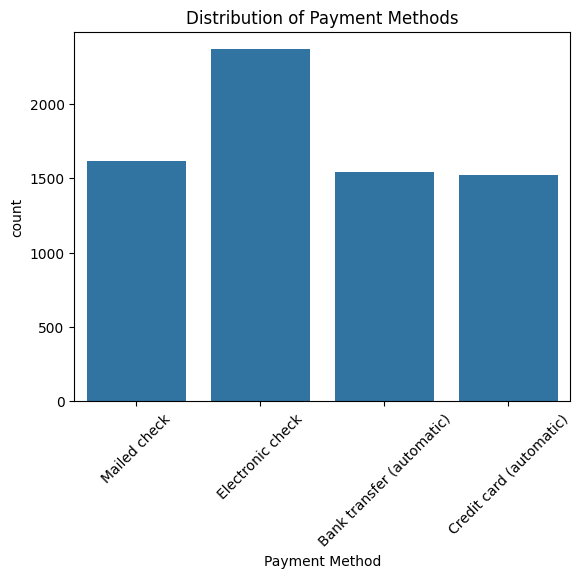

In [13]:
sns.countplot(x='Payment Method', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Payment Methods")
plt.show()

**After showing the distribution of payment methods, we want to see if the type of payment method affects the churn rate**

In [14]:
payment_churn = df.groupby('Payment Method')['Churn Value'].mean().reset_index()
display(payment_churn)

,Payment Method,Churn Value
0,Bank transfer (automatic),0.167098
1,Credit card (automatic),0.152431
2,Electronic check,0.452854
3,Mailed check,0.191067



## **Analysis**:
The distribution of payment methods shows us that customers are choosing Electronic checks which has a churn rate of 45.28% while each automatic payment has a churn rate of 15-16%. The distribution has a difference of 30% suggesting that customers that choose the automatic payment have a higher retention over customers who choose electronic check.

## **Proposed Solution**:

We suggest that the company encourages customers to use automatic payments, or remove electronic checks as a payment option, in order to increase customer retention.




---





# **How does the Distribution of Customers using different Internet Services affect the Churn Rate?**

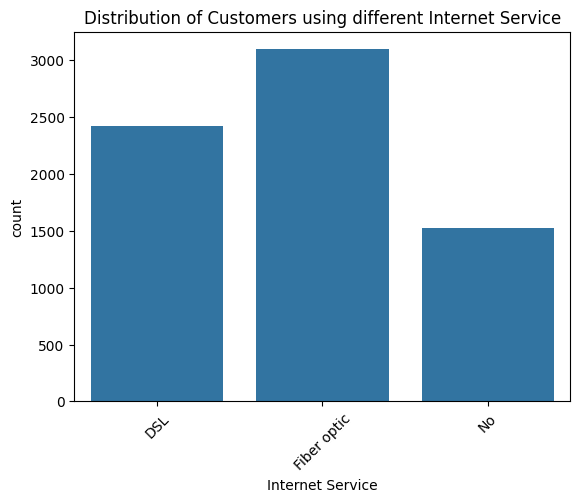

In [15]:
sns.countplot(x='Internet Service', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Customers using different Internet Service")
plt.show()

In [16]:
internet_service_churn = df.groupby('Internet Service')['Churn Value'].mean().reset_index()
display(internet_service_churn)

,Internet Service,Churn Value
0,DSL,0.189591
1,Fiber optic,0.418928
2,No,0.074050


In [37]:
#why are fiber optic customers leaving? Does Churn reason have a strong correlation

fiber_churn = df[
    (df['Internet Service'] == 'Fiber optic') &
    (df['Churn Label'] == 'Yes')
]

fiber_churn['Churn Reason'].value_counts()

,count
Churn Reason,
Attitude of support person,133
Competitor offered higher download speeds,130
Competitor offered more data,120
Competitor made better offer,104
Attitude of service provider,101
Don't know,97
Competitor had better devices,82
Price too high,71
Network reliability,67


# **Analysis:**
The distribution of internet services show that customers who use fiber optic have a churn rate of over 40%, significantly higher than other service types. This suggests that while fiber optic is supposed to offer higher speeds in comparison to DSL, customers seem to have a negative experience with fiber optic.

A deeper analysis of churn reasons of fiber optic customers revealed that churn reason was not just technical, but also service related. The most frequent reasons included issues with customer service support(attitude of support personnel and service providers), as well as better offerings from competitors(faster speeds, better pricing, more data).

According to the data, it suggests that poor customer service and poor fiber optic (speeds/data) are the main reasons why fiber optic customers are leaving.

# **Proposed Solution:**
We suggest that IBM should focus on both service quality improvements and better performance.

First, improving customer support is essential. Issues with support staff and service experience are the highest churn reasons. Our recommendation would be to implement customer service training, faster response times, and improve attidude. Better customer support can significantly improve customer satisfaction and rentention.

Additionally, IBM should review its competitive performance by evaluating its download speeds, data storage offerings, reliability and pricing. While improving performance, IBM can create incentives for customers by offering discounts and more competitive pricing relative to the performance they are getting.


---



## **Churn by Additional Services: (Tech Support and Device Protection)**

In [18]:
tech_support = df.groupby('Tech Support')['Churn Value'].agg(['mean','count']).reset_index()
tech_support.columns = ['Tech Support', 'Churn Rate', 'Customer Count']
display(tech_support)


,Tech Support,Churn Rate,Customer Count
0,No,0.416355,3473
1,No internet service,0.074050,1526
2,Yes,0.151663,2044


In [19]:
Device_Protection = df.groupby('Device Protection')['Churn Value'].agg(['mean','count']).reset_index()
Device_Protection.columns = ['Device Protection', 'Churn Rate', 'Customer Count']
display(Device_Protection)

,Device Protection,Churn Rate,Customer Count
0,No,0.391276,3095
1,No internet service,0.074050,1526
2,Yes,0.225021,2422


In [20]:
Online_security = df.groupby('Online Security')['Churn Value'].agg(['mean','count']).reset_index()
Online_security.columns = ['Online Security', 'Churn Rate', 'Customer Count']
display(Online_security)

,Online Security,Churn Rate,Customer Count
0,No,0.417667,3498
1,No internet service,0.074050,1526
2,Yes,0.146112,2019


In [21]:
Online_Backup = df.groupby('Online Backup')['Churn Value'].agg(['mean','count']).reset_index()
Online_Backup.columns = ['Online Backup', 'Churn Rate', 'Customer Count']
display(Online_Backup)

,Online Backup,Churn Rate,Customer Count
0,No,0.399288,3088
1,No internet service,0.074050,1526
2,Yes,0.215315,2429


# **Insights:**
Our analysis reveals a significant correlation between the adoption of additional services and customer retention. Customers who did not buy the additional services showed remarkleably higher churn rates compared to those with additional services. Given that the customer count is split nearly equally, we suggest that IBM develops a strategy to increase conversion from single service customers itno multi-services.



---



# **ML: Logistic Regression**

This section outlines the process for building and evaluating a logistic regression model to predict customer churn:

**Step 1:** Preprocess and standardize the data

**Step 2:** Define feature set and target variable, separating independent variables (X) and the dependent variable (y)

**Step 3:** Split dataset into training and testing subsets

**Step 4:** Fit model to the data and predict

**Step 5:** Evaluate model performance by generating classification report

**Step 6:** Generate confusion matrix to validate accuracy results(f1-score)


## **Step 1:** standardize the data

In [22]:
# Create a list of explanatory variables
categorical_features = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method'
]

In [23]:
# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
# View the new columns
df_encoded.head()

,Count,Country,State,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,United States,California,Los Angeles,90003,Male,No,No,No,2,...,False,False,False,False,False,False,True,False,False,True
1,1,United States,California,Los Angeles,90005,Female,No,No,Yes,2,...,False,False,False,False,False,False,True,False,True,False
2,1,United States,California,Los Angeles,90006,Female,No,No,Yes,8,...,False,True,False,False,False,False,True,False,True,False
3,1,United States,California,Los Angeles,90010,Female,No,Yes,Yes,28,...,False,True,False,True,False,False,True,False,True,False
4,1,United States,California,Los Angeles,90015,Male,No,No,Yes,49,...,False,True,False,False,False,False,True,False,False,False


In [24]:
# Convert Total Charges to numeric, turning errors (like empty spaces) into NaN
df_encoded['Total Charges'] = pd.to_numeric(df_encoded['Total Charges'], errors='coerce')

# Fill any resulting NaNs with 0 or the mean
df_encoded['Total Charges'] = df_encoded['Total Charges'].fillna(0)

## **Step 2:** Define feature set and target variable, separating independent variables (X) and the dependent variable (y)

In [25]:
# Create a list of columns to drop from X (non-numeric, metadata, or target-related)
columns_to_drop_from_X = [
    'Churn Value', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason',
    'Count', 'Country', 'State', 'City', 'Zip Code',
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Streaming TV', 'Streaming Movies'
]

# Create a data frame X for explanatory variables and data frame y for target variable
X = df_encoded.drop(columns=columns_to_drop_from_X, axis=1)
y = df_encoded['Churn Value']

## **Step 3:** Split dataset into training and testing subsets

In [26]:
from sklearn.model_selection import train_test_split

# Split the dataset for training and testing using 75% and 25% split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=99)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
# Look at the shape of the test data subset
x_test.shape, y_test.shape

((1761, 22), (1761,))

In [29]:
# Look at the head of the training data subset
x_train.head()

,Tenure Months,Monthly Charges,Total Charges,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,...,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
5711,38,24.85,955.75,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4124,50,70.50,3486.65,True,False,True,False,False,False,True,...,False,False,False,True,False,True,True,True,False,False
4527,55,20.00,1087.25,True,False,False,False,True,True,False,...,True,False,True,False,False,False,False,True,False,False
894,68,83.00,5685.80,True,False,True,True,False,False,False,...,False,False,False,False,True,False,True,False,True,False
3914,46,84.80,3958.85,True,False,True,True,False,False,False,...,False,True,False,True,False,False,True,False,False,False


## **Step 4:** Fit model to the data and predict

In [30]:
# Here the fitted model is named as logmodel
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=200)
logmodel.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=200)

In [31]:
# Use x_test hold-out subset to predict.
# y_test is for comparing predicted and actual values with y_predicted

y_predict = logmodel.predict(x_test_scaled)

## **Step 5:** Evaluate model performance by generating classification report

In [39]:
# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_predict))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.67      0.56      0.61       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



## **Step 6:** Generate confusion matrix to validate accuracy results(f1-score)




In [38]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))



Confusion Matrix:
 [[1165  129]
 [ 207  260]]
Accuracy: 0.8091993185689949


The logistic regression model was developed to predict churn value based on the 10 variables we selected. The dataset was split into training and testing sets (75% training and 25% testing data)

1. Overall Effectiveness
The Logistic Regression model achieved an overall accuracy of 81% on the test set. This confirms that the model correctly predicts the churn status for 81% of all customers in the test data.

2. Identifying At-Risk Customers (Class 1)
Precision (67%): When the model flags a customer as "Likely to Churn," it is correct 67% of the time. This indicates a solid level of reliability for targeting retention efforts.

Recall (56%): The model successfully identifies 56% of all customers who actually churned. This is the portion of "at-risk" customers we can proactively reach out to.

F1-Score (61%): This harmonic mean of 61% provides a balanced measure of our predictive capability for the churn class.

